In [2]:
import os
os.chdir("..")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import deque

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

# Loading data

In [6]:
df = pd.read_csv("data/merged/merged_v6.csv")
df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_convert("Europe/Kyiv")

In [7]:
df.head()

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day
0,2,2022-03-28 00:00:00+03:00,0,0.4,-2.2,43.82,-10.5,0.0,0.0,0,7.6,314.0,1029.0,24.1,2.0,0.0,0,13,5,0,0,4,4,0,0,0,0,0,0,5,5,5,4,0,86,289,-3,0,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
1,2,2022-03-28 01:00:00+03:00,0,-0.1,-2.5,45.43,-10.5,0.0,0.0,0,6.8,308.6,1029.0,24.1,4.2,0.0,0,8,2,0,0,3,3,0,0,0,0,0,0,1,1,1,4,0,45,285,-3,1,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
2,2,2022-03-28 02:00:00+03:00,0,-0.6,-2.3,47.87,-10.3,0.0,0.0,0,5.0,305.7,1029.0,24.1,3.1,0.0,0,7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,28,269,-2,2,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
3,2,2022-03-28 03:00:00+03:00,0,-1.1,-1.1,51.24,-9.9,0.0,0.0,0,4.0,289.8,1029.0,24.1,1.8,0.0,0,11,10,0,0,0,0,2,0,2,0,0,0,9,9,9,0,2,26,275,10,3,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
4,2,2022-03-28 04:00:00+03:00,0,-1.4,-1.4,52.80,-9.8,0.0,0.0,0,3.6,245.2,1029.0,24.1,0.0,0.0,0,9,1,0,0,6,6,2,0,2,0,0,0,1,1,2,6,2,27,283,-9,4,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 734233 entries, 0 to 734232
Data columns (total 68 columns):
 #   Column                     Non-Null Count   Dtype                      
---  ------                     --------------   -----                      
 0   region_id                  734233 non-null  int64                      
 1   time                       734233 non-null  datetime64[us, Europe/Kyiv]
 2   alarm                      734233 non-null  int64                      
 3   hour_temp                  734233 non-null  float64                    
 4   hour_feelslike             734233 non-null  float64                    
 5   hour_humidity              734233 non-null  float64                    
 6   hour_dew                   734233 non-null  float64                    
 7   hour_precip                734233 non-null  float64                    
 8   hour_precipprob            734233 non-null  float64                    
 9   hour_preciptype            734233 non-null  int6

# Extracting features

Calculate distance in regions to nearest region with alarm

In [9]:
%%time
# Neighbor adjacency map using region_ids from your CSV:
# 1=Crimea, 2=Vinnytsia, 3=Volyn, 4=Dnipropetrovsk, 5=Donetsk,
# 6=Zhytomyr, 7=Zakarpattia, 8=Zaporizhzhia, 9=Ivano-Frankivsk,
# 10=Kyiv, 11=Kirovohrad, 12=Luhansk, 13=Lviv, 14=Mykolaiv,
# 15=Odessa, 16=Poltava, 17=Rivne, 18=Sumy, 19=Ternopil,
# 20=Kharkiv, 21=Kherson, 22=Khmelnytskyi, 23=Cherkasy,
# 24=Chernivtsi, 25=Chernihiv

NEIGHBORS = {
    1:  [8, 14, 15],
    2:  [6, 10, 23, 11, 15, 24, 22],
    3:  [17, 13],
    4:  [16, 20, 8, 21, 14, 11, 5],
    5:  [20, 12, 8, 4],
    6:  [10, 25, 17, 22, 2],
    7:  [13, 9],
    8:  [4, 5, 21],
    9:  [13, 7, 24, 19],
    10: [25, 18, 16, 23, 2, 6],
    11: [23, 16, 4, 14, 15, 2],
    12: [20, 5],
    13: [3, 17, 19, 9, 7],
    14: [15, 21, 4, 11],
    15: [14, 11, 2, 24],
    16: [18, 20, 4, 11, 23, 25, 10],
    17: [3, 13, 19, 22, 6],
    18: [25, 16, 20],
    19: [17, 22, 13, 9, 24],
    20: [18, 16, 4, 5, 12],
    21: [14, 4, 8],
    22: [6, 2, 19, 17, 24],
    23: [10, 16, 4, 11, 2, 25],
    24: [9, 22, 2, 15, 19],
    25: [10, 18, 16, 23],
}

# Precompute BFS distances between all region pairs once at import time
def _bfs_distances(source, neighbors_map):
    """Returns dict of {region_id: hops} from source via BFS."""
    dist = {source: 0}
    queue = deque([source])
    while queue:
        node = queue.popleft()
        for neighbor in neighbors_map[node]:
            if neighbor not in dist:
                dist[neighbor] = dist[node] + 1
                queue.append(neighbor)
    return dist

ALL_GRAPH_DISTANCES = {
    r: _bfs_distances(r, NEIGHBORS)
    for r in NEIGHBORS
}

def dist_to_nearest_alarm(row, alarm_lookup, region_col="region_id", time_col="time", alarm_col="alarm"):
    """
    For use with df.apply(). Returns:
      0    — current region has an alarm
      hops — min number of borders to cross to reach a region with alarm
      -1   — no alarms anywhere at this timestamp
    
    Parameters:
        row          - DataFrame row (from apply axis=1)
        alarm_lookup - dict mapping (timestamp, region_id) -> alarm value;
                       build it once before calling apply (see usage below)
        region_col   - name of the region ID column
        time_col     - name of the timestamp column
        alarm_col    - name of the alarm status column
    """
    current_region = row[region_col]
    current_time   = row[time_col]

    # Current region has alarm → distance is 0
    if row[alarm_col]:
        return 0

    distances_from_current = ALL_GRAPH_DISTANCES[current_region]

    min_hops = float("inf")
    for region_id in NEIGHBORS:
        if region_id == current_region:
            continue
        try:
            has_alarm = alarm_lookup[(current_time, region_id)]
        except KeyError:
            continue
        if has_alarm:
            hops = distances_from_current.get(region_id, float("inf"))
            if hops < min_hops:
                min_hops = hops

    return -1 if min_hops == float("inf") else min_hops


# --- Usage ---

# Build lookup ONCE before apply (much faster than indexing df inside apply)
alarm_lookup = df.set_index(["time", "region_id"])["alarm"].to_dict()

df["hops_to_nearest_alarm"] = df.apply(
    dist_to_nearest_alarm,
    axis=1,
    alarm_lookup=alarm_lookup,
    region_col="region_id",
    time_col="time",
    alarm_col="alarm",
)

df["hops_to_nearest_alarm"] = df.groupby("region_id")["hops_to_nearest_alarm"].shift(1)

CPU times: total: 27.5 s
Wall time: 28 s


In [10]:
df.hops_to_nearest_alarm.unique()

array([nan,  1.,  2., -1.,  0.,  3.,  4.,  6.,  5.])

Calculate number of alarms in all regions by hour

In [11]:
all_alarms = df.groupby("time")["alarm"].sum().rename("num_alarms").reset_index()

df = pd.merge(df, all_alarms, on="time", how="left")
# df["other_alarms_count"] = df["num_alarms"] - df["alarm"]
for i in range(12):
    df[f"alarms_count_{i+1}h_ago"] = df["num_alarms"].shift(i+1)

df = df.drop(columns="num_alarms")

Add lag for 1-24 hours

In [12]:
for i in range(24):
    df[f"alarm_status_{i+1}h_ago"] = df.groupby("region_id")["alarm"].shift(i+1)

In [13]:
df = df.dropna(axis=0).reset_index(drop=True)

In [14]:
df.head()

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day,hops_to_nearest_alarm,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
0,2,2022-03-29 00:00:00+03:00,0,6.8,5.1,37.25,-6.8,0.0,0.0,0,8.3,229.7,1015.0,24.1,0.0,0.0,0,13,0,0,0,8,8,0,0,0,0,0,0,0,0,2,8,0,51,337,-12,0,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1.0,10.0,7.0,6.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,14.0,15.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2022-03-29 01:00:00+03:00,0,6.3,4.9,39.45,-6.5,0.0,0.0,0,6.8,227.6,1015.0,24.1,0.0,0.0,0,6,1,0,0,4,4,0,0,2,0,0,0,1,1,2,4,0,41,335,1,1,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1.0,9.0,10.0,7.0,6.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,14.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2022-03-29 02:00:00+03:00,0,6.0,4.7,40.59,-6.4,0.0,0.0,0,6.5,225.0,1014.0,24.1,0.0,0.0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,20,329,0,2,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1.0,4.0,9.0,10.0,7.0,6.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,2022-03-29 03:00:00+03:00,1,6.2,4.5,40.34,-6.3,0.0,0.0,0,7.9,231.3,1013.0,24.1,0.0,0.0,0,32,26,0,0,4,4,2,0,4,0,0,0,26,26,26,4,2,39,350,25,3,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1.0,1.0,4.0,9.0,10.0,7.0,6.0,6.0,0.0,1.0,4.0,4.0,3.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,2022-03-29 04:00:00+03:00,1,5.9,4.2,42.14,-6.0,0.0,0.0,0,7.9,231.3,1012.0,24.1,0.0,0.0,0,24,2,0,0,21,21,2,0,0,0,0,0,2,2,4,21,4,57,365,-24,4,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,0.0,19.0,1.0,4.0,9.0,10.0,7.0,6.0,6.0,0.0,1.0,4.0,4.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
df.to_csv("data/merged/merged_preprocessed.csv", index=False)

# Explorary data analysis

In [16]:
df = pd.read_csv("data/merged/merged_preprocessed.csv")
df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_convert("Europe/Kyiv")

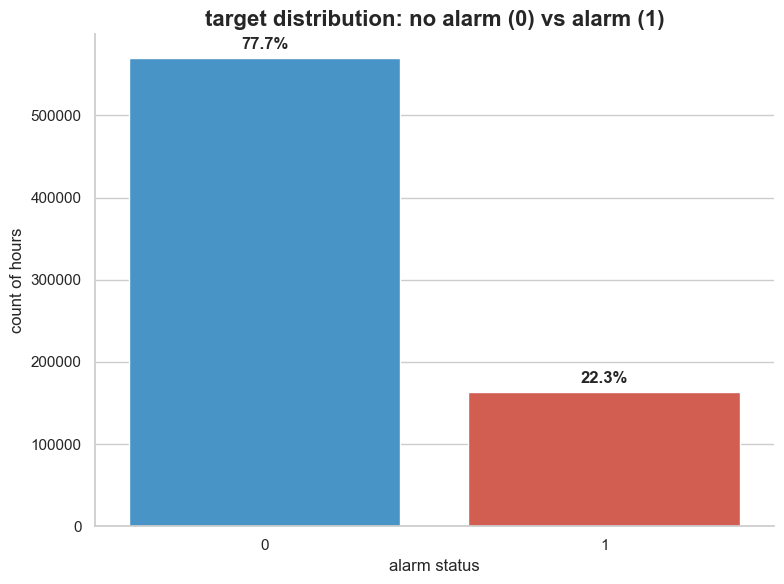

In [39]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='alarm', palette=['#3498db', '#e74c3c'])
plt.title("target distribution: no alarm (0) vs alarm (1)", fontsize=16, fontweight='bold')
plt.xlabel("alarm status", fontsize=12)
plt.ylabel("count of hours", fontsize=12)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y + total*0.01), ha='center', va='bottom', fontsize=12, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

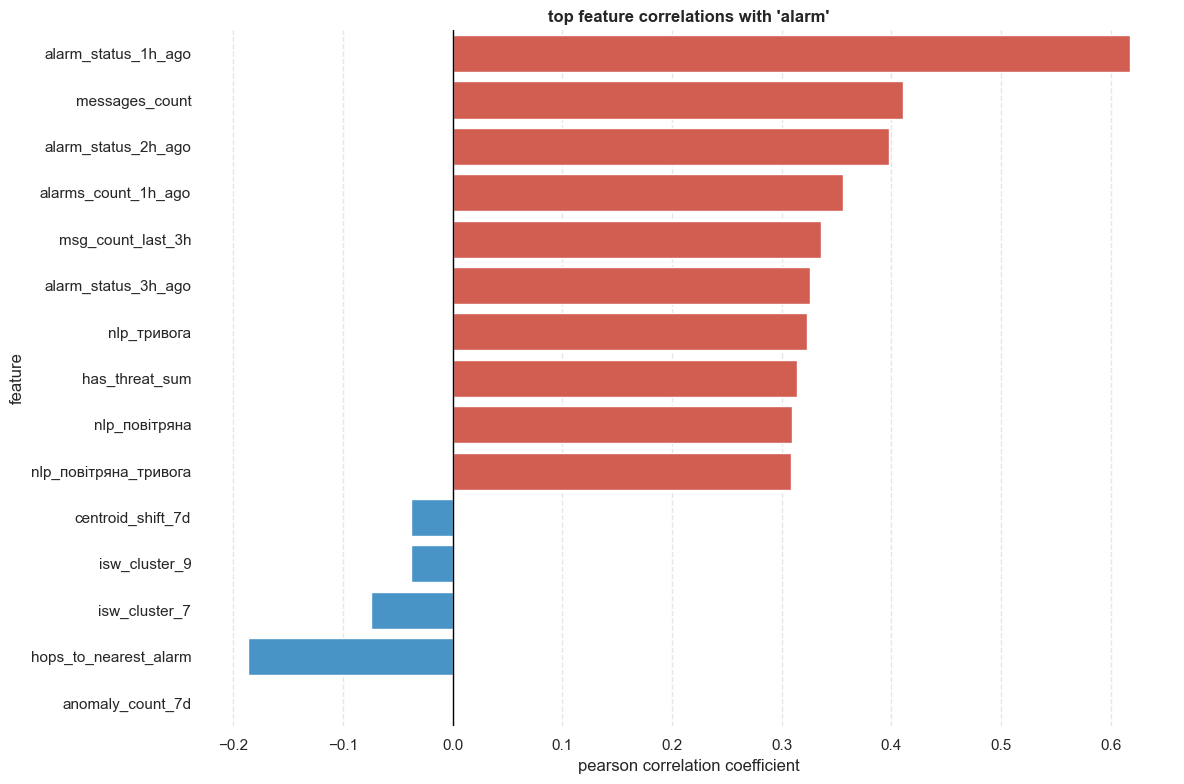

In [40]:
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'int32']).columns

corr_with_target = df[numeric_cols].corr()['alarm'].sort_values(ascending=False).drop('alarm')

top_correlations = pd.concat([corr_with_target.head(10), corr_with_target.tail(5)])

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_correlations.values]
sns.barplot(x=top_correlations.values, y=top_correlations.index, palette=colors)

plt.title("top feature correlations with 'alarm'",fontweight='bold')
plt.xlabel("pearson correlation coefficient")
plt.ylabel("feature")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) 

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

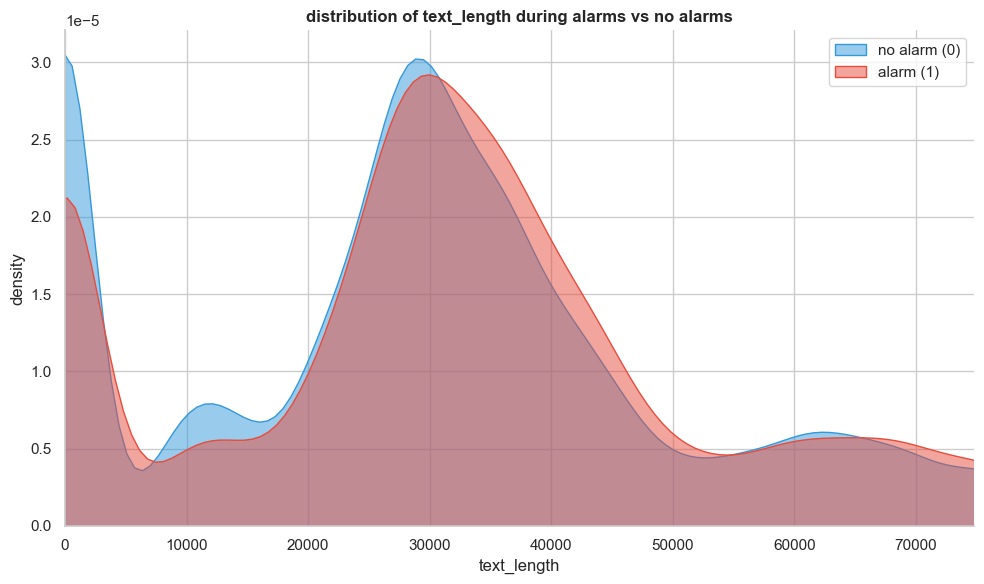

In [41]:
plt.figure(figsize=(10, 6))

feature_to_plot = 'text_length'

if feature_to_plot in df.columns:
    sns.kdeplot(data=df[df['alarm'] == 0], x=feature_to_plot, label='no alarm (0)', fill=True, color='#3498db', alpha=0.5, bw_adjust=1.5)
    sns.kdeplot(data=df[df['alarm'] == 1], x=feature_to_plot, label='alarm (1)', fill=True, color='#e74c3c', alpha=0.5, bw_adjust=1.5)
    
    plt.title(f"distribution of {feature_to_plot} during alarms vs no alarms", fontweight='bold')
    plt.xlabel(feature_to_plot)
    plt.ylabel("density")
    
    upper_limit = df[feature_to_plot].quantile(0.95)
    if upper_limit > 0:
        plt.xlim(0, upper_limit) 
        
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

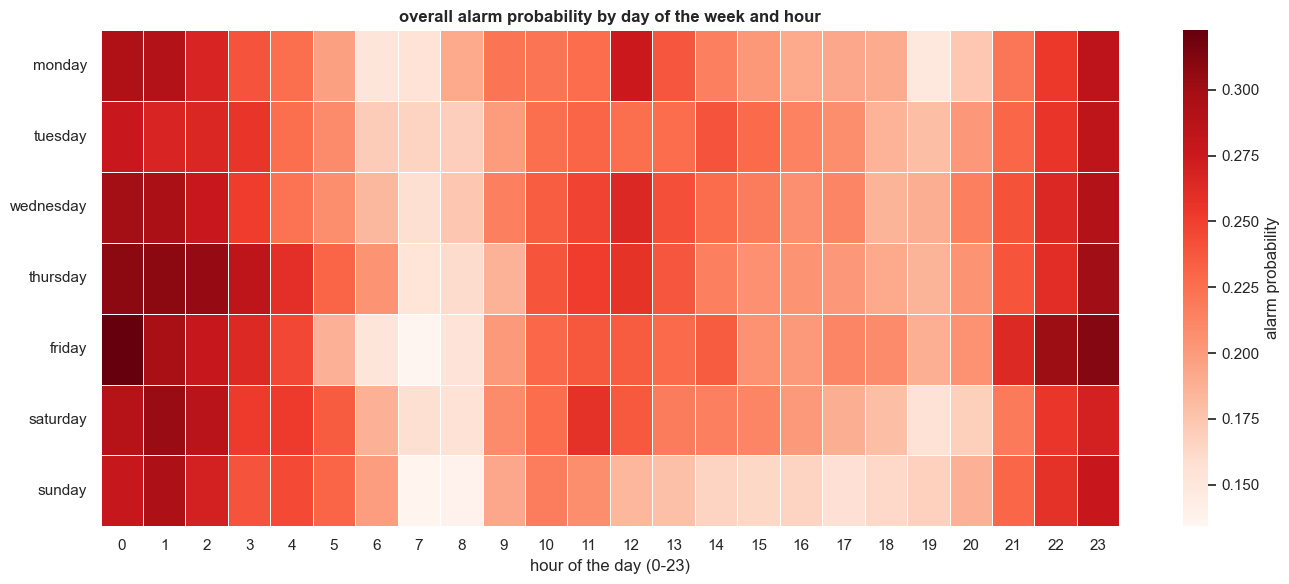

In [42]:
df_temp = df.copy()

df_temp['time'] = pd.to_datetime(df_temp['time'], errors='coerce')
df_temp['day_of_week'] = df_temp['time'].dt.day_name().str.lower()
df_temp['hour_of_day'] = df_temp['time'].dt.hour

alarm_prob = df_temp.pivot_table(index='day_of_week', columns='hour_of_day', values='alarm', aggfunc='mean')

days_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
alarm_prob = alarm_prob.reindex(days_order)

plt.figure(figsize=(14, 6))
sns.heatmap(alarm_prob, cmap='Reds', linewidths=.5, cbar_kws={'label': 'alarm probability'})

plt.title("overall alarm probability by day of the week and hour", fontweight='bold')
plt.xlabel("hour of the day (0-23)")
plt.ylabel("")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

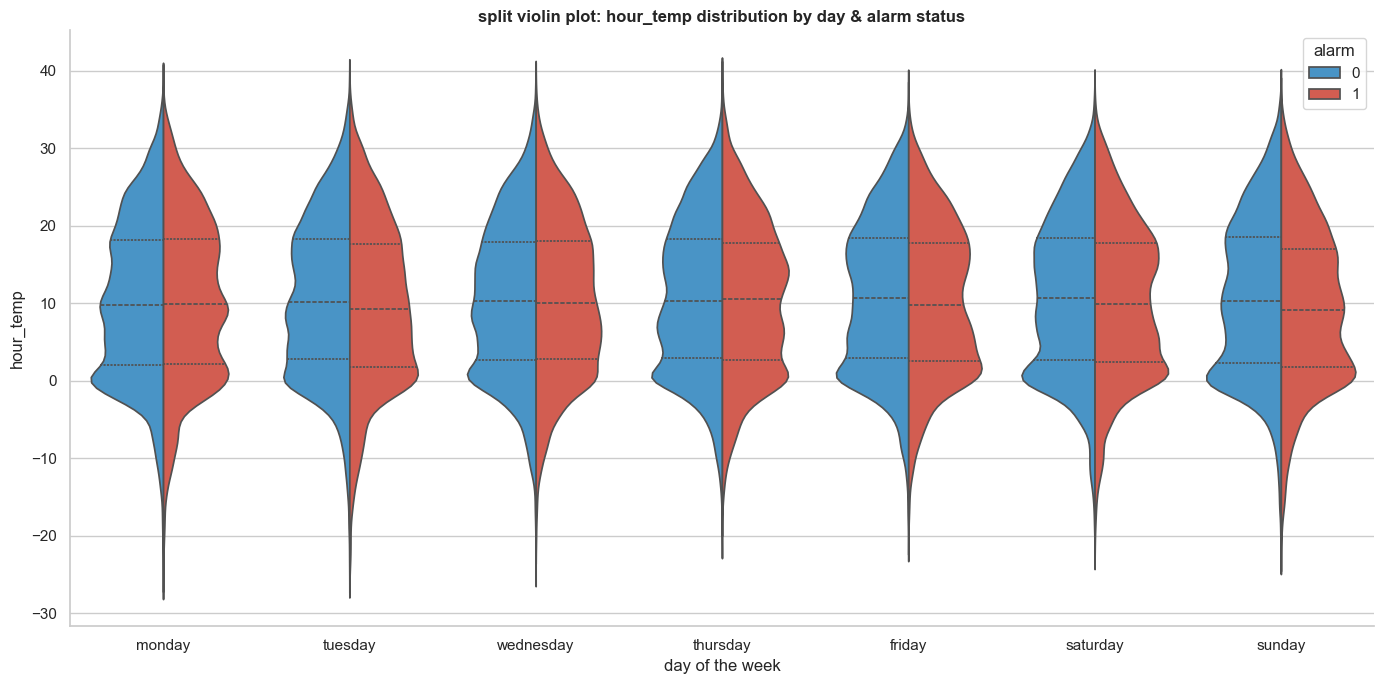

In [43]:
plt.figure(figsize=(14, 7))

feature_for_violin = 'hour_temp' if 'hour_temp' in df.columns else df.select_dtypes(include='number').columns[5]

sns.violinplot(
    data=df_temp, 
    x='day_of_week', 
    y=feature_for_violin, 
    hue='alarm', 
    split=True,
    inner='quartile',
    palette=['#3498db', '#e74c3c'],
    order=['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
)

plt.title(f"split violin plot: {feature_for_violin} distribution by day & alarm status", fontweight='bold')
plt.xlabel("day of the week")
plt.ylabel(feature_for_violin)
plt.legend(title="alarm", loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

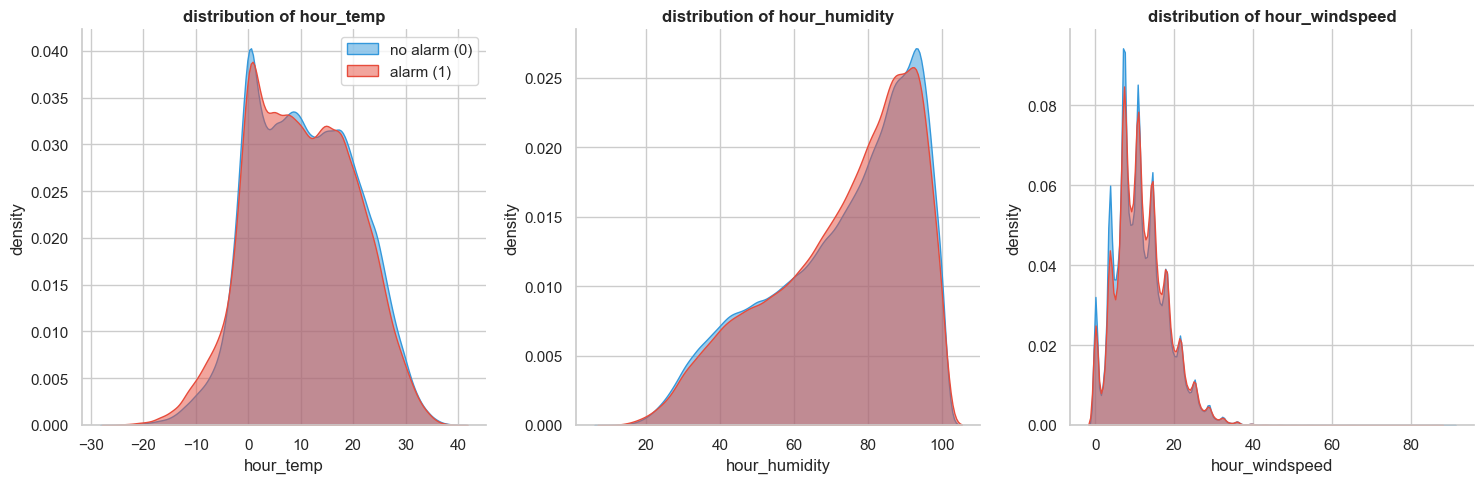

In [44]:
features_to_plot = ['hour_temp', 'hour_humidity', 'hour_windspeed']
features_to_plot = [f for f in features_to_plot if f in df.columns]

if len(features_to_plot) > 0:
    fig, axes = plt.subplots(1, len(features_to_plot), figsize=(15, 5))
    
    if len(features_to_plot) == 1:
        axes = [axes]

    for i, feature in enumerate(features_to_plot):
        sns.kdeplot(data=df[df['alarm'] == 0], x=feature, fill=True, color='#3498db', label='no alarm (0)', ax=axes[i], alpha=0.5)
        sns.kdeplot(data=df[df['alarm'] == 1], x=feature, fill=True, color='#e74c3c', label='alarm (1)', ax=axes[i], alpha=0.5)
        
        axes[i].set_title(f"distribution of {feature}", fontweight='bold')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("density")
        
    axes[0].legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

<Figure size 1200x600 with 0 Axes>

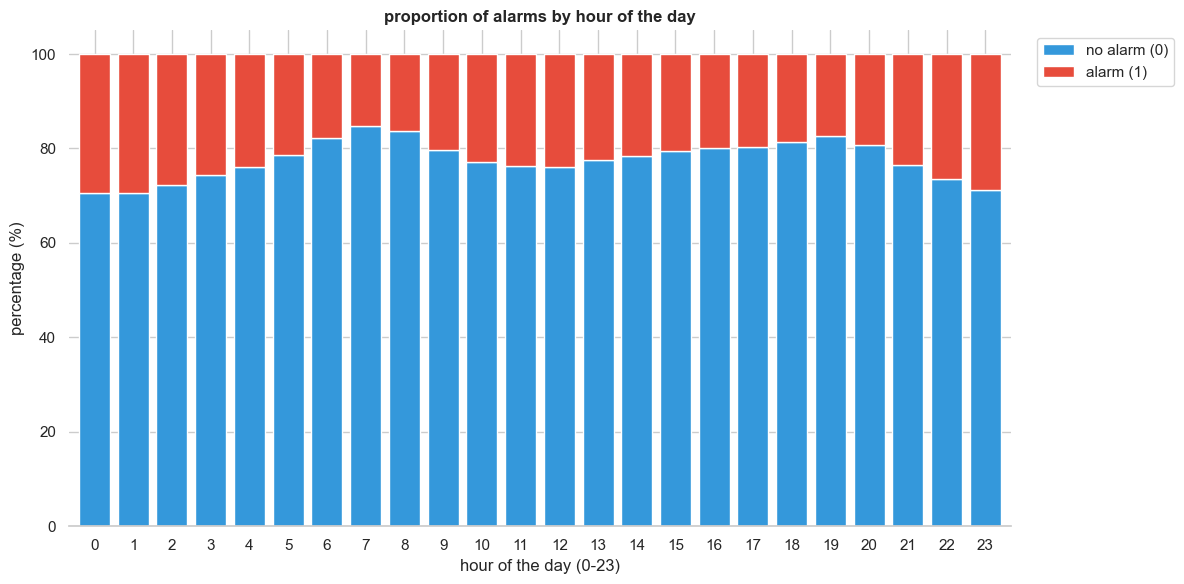

In [46]:
plt.figure(figsize=(12, 6))

df['temp_hour'] = pd.to_datetime(df['time']).dt.hour

cross_tab = pd.crosstab(df['temp_hour'], df['alarm'], normalize='index') * 100

ax = cross_tab.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    color=['#3498db', '#e74c3c'], 
    edgecolor='white',
    width=0.8
)

plt.title("proportion of alarms by hour of the day", fontweight='bold')
plt.xlabel("hour of the day (0-23)")
plt.ylabel("percentage (%)",)
plt.xticks(rotation=0)

plt.legend(['no alarm (0)', 'alarm (1)'], bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(left=True)
plt.tight_layout()
plt.show()

df.drop(columns=['temp_hour'], inplace=True)

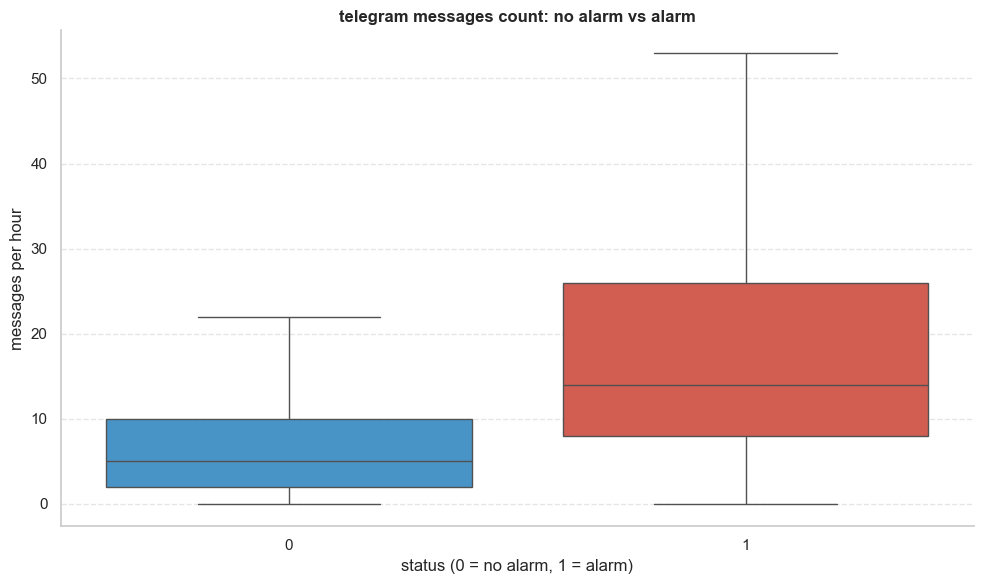

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x='alarm', 
    y='messages_count', 
    palette=['#3498db', '#e74c3c'], 
    showfliers=False
)

plt.title("telegram messages count: no alarm vs alarm", fontweight='bold')
plt.xlabel("status (0 = no alarm, 1 = alarm)")
plt.ylabel("messages per hour")

plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

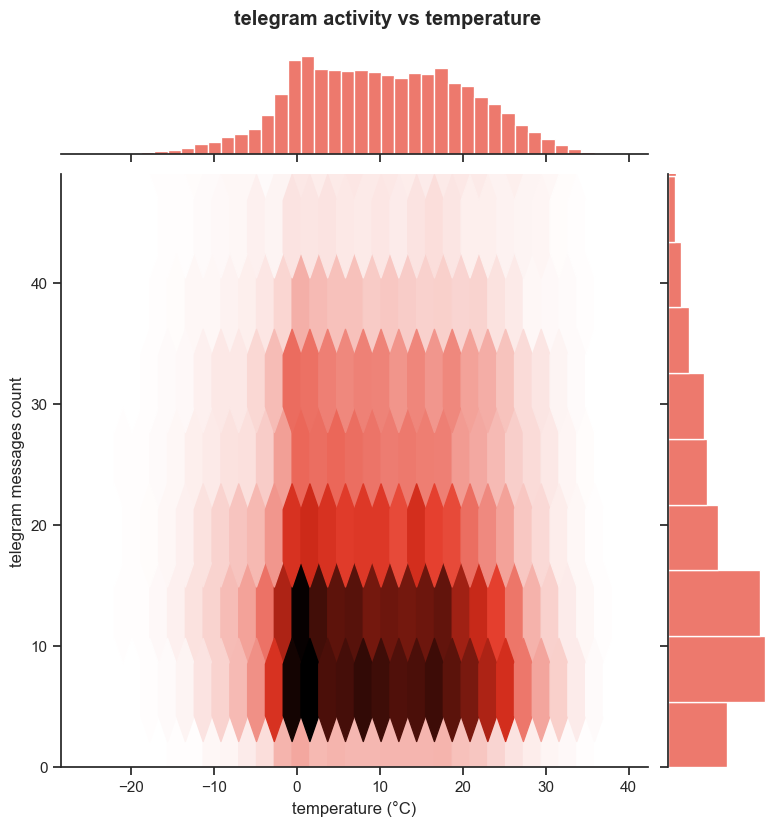

In [48]:
df_alarms_only = df[df['alarm'] == 1]

sns.set_theme(style="ticks")

g = sns.jointplot(
    data=df_alarms_only, 
    x="hour_temp", 
    y="messages_count", 
    kind="hex", 
    color="#e74c3c", 
    gridsize=30, 
    height=8,
    marginal_kws=dict(bins=40, fill=True)
)

g.fig.suptitle("telegram activity vs temperature", fontweight='bold', y=1.03)
g.set_axis_labels("temperature (°C)", "telegram messages count")

plt.ylim(0, df_alarms_only['messages_count'].quantile(0.95))

plt.show()

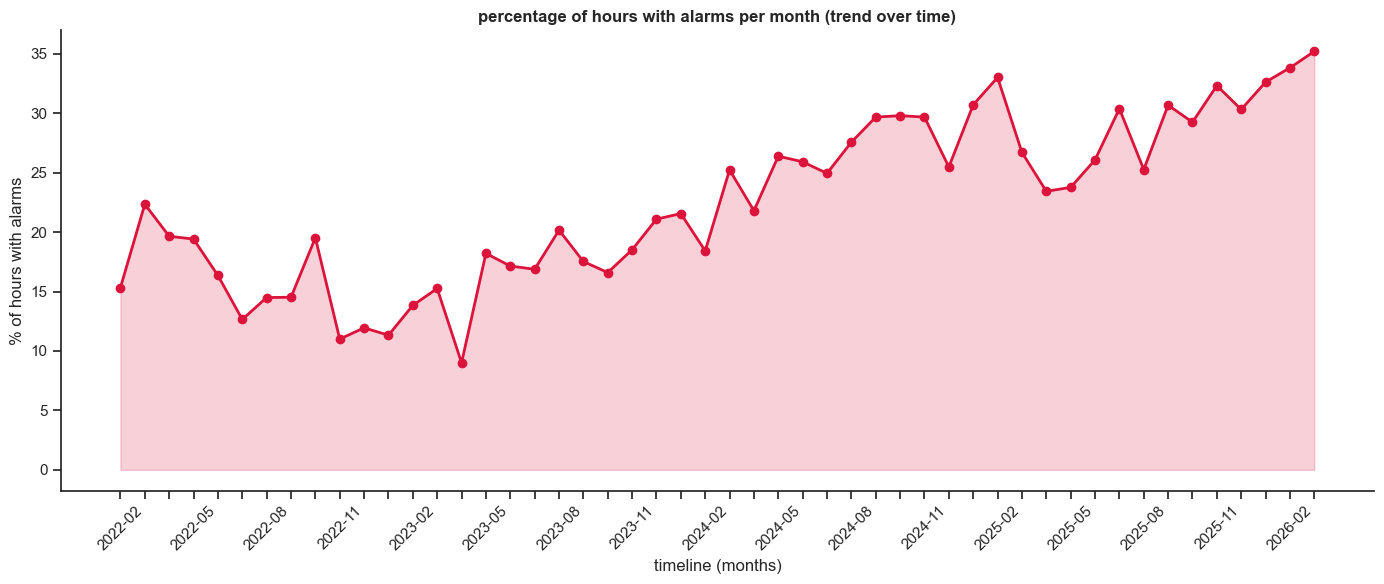

In [49]:
plt.figure(figsize=(14, 6))

df['year_month'] = pd.to_datetime(df['time']).dt.to_period('M')

monthly_trend = df.groupby('year_month')['alarm'].mean() * 100

plt.plot(monthly_trend.index.astype(str), monthly_trend.values, color='crimson', marker='o', linewidth=2)
plt.fill_between(monthly_trend.index.astype(str), monthly_trend.values, color='crimson', alpha=0.2)

plt.title("percentage of hours with alarms per month (trend over time)", fontweight='bold')
plt.xlabel("timeline (months)")
plt.ylabel("% of hours with alarms")

plt.xticks(rotation=45)
ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 3 != 0:
        label.set_visible(False)

sns.despine()
plt.tight_layout()
plt.show()

df.drop(columns=['year_month'], inplace=True)

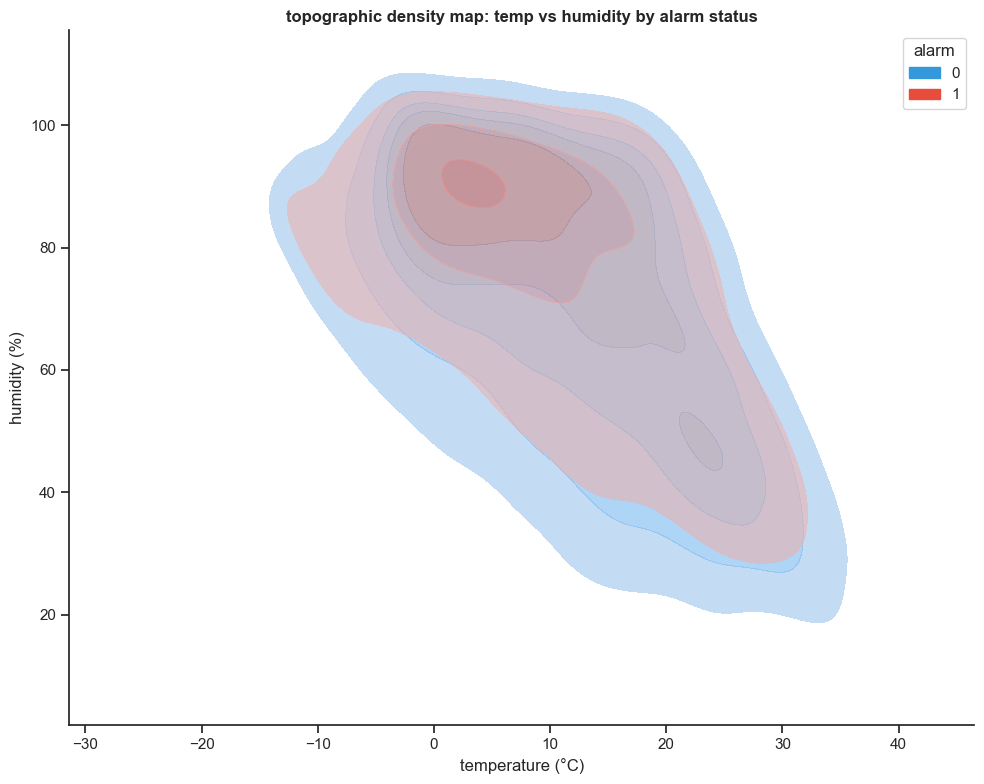

In [50]:
plt.figure(figsize=(10, 8))

df_sample = df.sample(n=min(10000, len(df)), random_state=42)

sns.kdeplot(
    data=df_sample, 
    x="hour_temp", 
    y="hour_humidity", 
    hue="alarm", 
    fill=True, 
    alpha=0.6, 
    palette=['#3498db', '#e74c3c'], 
    thresh=0.05,
    levels=6 
)

plt.title("topographic density map: temp vs humidity by alarm status", fontweight='bold')
plt.xlabel("temperature (°C)")
plt.ylabel("humidity (%)")

sns.despine()
plt.tight_layout()
plt.show()

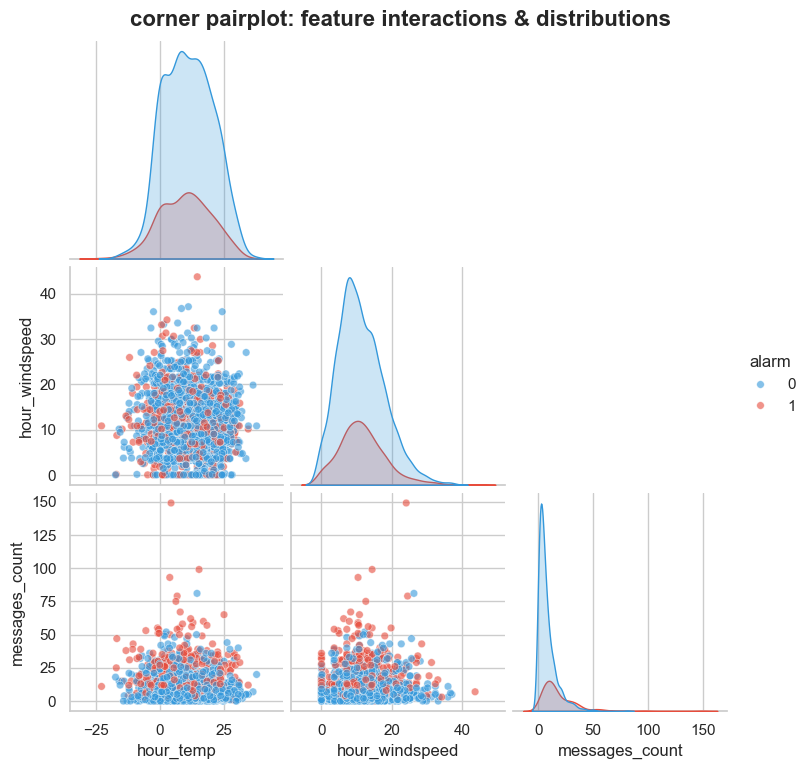

In [ ]:
features_to_compare = ['hour_temp', 'hour_windspeed', 'messages_count', 'alarm']
existing_features = [f for f in features_to_compare if f in df.columns]

df_pair_sample = df.dropna(subset=existing_features).sample(n=min(2000, len(df)), random_state=42)

g = sns.pairplot(
    df_pair_sample[existing_features], 
    hue='alarm', 
    palette=['#3498db', '#e74c3c'], 
    corner=True, 
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'w'}
)

g.fig.suptitle("corner pairplot: feature interactions & distributions", fontweight='bold', y=1.02)
plt.show()

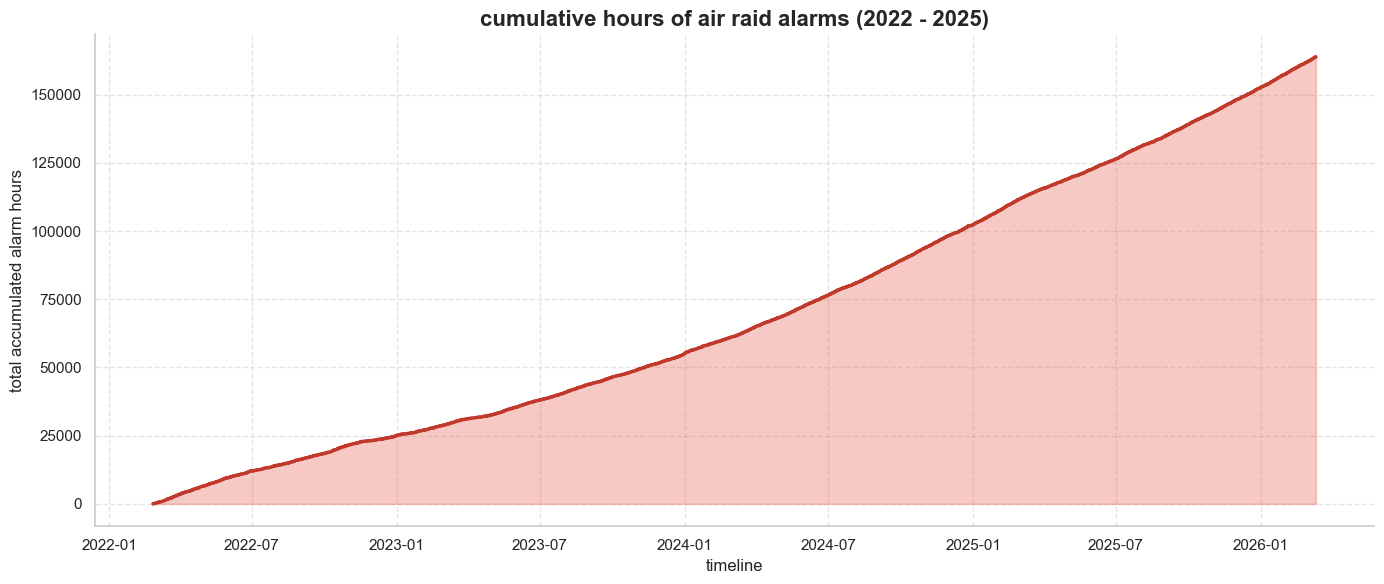

In [ ]:
plt.figure(figsize=(14, 6))

df_sorted = df.sort_values('time').copy()
df_sorted['time'] = pd.to_datetime(df_sorted['time'])

df_sorted['cumulative_alarms'] = df_sorted['alarm'].cumsum()

plt.plot(df_sorted['time'], df_sorted['cumulative_alarms'], color='#c0392b', linewidth=2.5)
plt.fill_between(df_sorted['time'], df_sorted['cumulative_alarms'], color='#e74c3c', alpha=0.3)

plt.title("cumulative hours of air raid alarms (2022 - 2025)", fontweight='bold')
plt.xlabel("timeline", fontsize=12)
plt.ylabel("total accumulated alarm hours")

plt.grid(axis='both', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

## Сonclusions

### Data Preparation
- i loaded the final merged dataset and verified the overall structure to ensure all temporal data aligns correctly
- i handled remaining missing values and checked the data types to confirm that numerical and categorical features are ready for analysis
- i applied necessary transformations and saved the preprocessed dataset for the machine learning modeling phase

### Exploratory Data Analysis
- i analyzed the target variable ('alarm') and found that the dataset is highly imbalanced, as alarms make up a relatively small percentage of the total hours
- i built a correlation matrix and identified which external features have the strongest relationship with the probability of an air raid alarm
- i plotted density distributions and observed that certain environmental and external conditions slightly shift during alarm periods compared to calm periods
- i analyzed the temporal patterns and noticed that the proportion of alarms significantly increases during specific hours of the day and specific days of the week